# Computational Equivalence Benchmark: `pi-oplsda` vs. `ropls`

## Overview
This notebook provides a rigorous mathematical validation of the **`pi-oplsda`** Python package by benchmarking its results against the industry-standard **`ropls`** package from Bioconductor. 

Orthogonal Partial Least Squares Discriminant Analysis (OPLS-DA) is a powerful supervised multi-variate analysis method used in metabolomics to model the relationship between a data matrix $X$ and a class vector $y$. The goal of this benchmark is to demonstrate that `pi-oplsda` achieves numerical identity with `ropls` across all critical model parameters.

---

## Technical Stack
* **Python Environment**: `pi-oplsda` (v1.0.0), `pandas`, `numpy`, `scipy`.
* **R Environment**: `R 4.5.3`, `ropls`.
* **Bridge**: `rpy2` utilizing a robust S4-object extraction strategy to ensure data integrity during cross-language transfer.

---

## Benchmark Dataset: Sacurine
We utilize the **Sacurine** dataset, a gold-standard benchmark in computational metabolomics. 
* **Samples ($n$)**: 183 human urine samples.
* **Features ($p$)**: 109 metabolites (LC-MS positive mode).
* **Target ($y$)**: Biological gender (Male vs. Female).

---

## Validation Metrics
The consistency of the implementation is evaluated across three distinct dimensions:

### 1. Global Model Quality
We compare the summary statistics that define the model's predictive power and fit:
* **$R^2X(cum)$**: Cumulative fraction of the variation of the $X$ matrix explained by the model.
* **$R^2Y(cum)$**: Cumulative fraction of the variation of the $y$ vector explained by the model.
* **$Q^2(cum)$**: Cumulative fraction of the total variation of $y$ predicted by $7$-fold cross-validation.
* **$RMSEE$**: Root Mean Square Error of Estimation.

### 2. Variable Importance
* **VIP (Variable Importance in Projection)**: We validate the VIP scores calculated using the `ropls` specific algorithm to ensure feature selection consistency.

### 3. Latent Space Representation
The OPLS-DA model decomposes the $X$ matrix as follows:
$$X = T_p P_p^T + T_o P_o^T + E$$
Where:
* $T_p, P_p$: Predictive scores and loadings.
* $T_o, P_o$: Orthogonal scores and loadings.
* $E$: Residual matrix.

We calculate the **Pearson Correlation Coefficient** between the Python and R results for these vectors to ensure the latent space projection is identical.

---

> **Note on Mathematical Signage**: 
> In eigen-decomposition based methods, the signs of scores and loadings are arbitrary (subject to $T \cdot P^T$). A correlation of $-1.0$ is mathematically equivalent to $1.0$ in terms of model interpretation. This benchmark accounts for potential sign flips.

## Step 1: Environment Initialization & `rpy2` Configuration
This step configures the communication bridge between Python and R. By specifying `R_HOME` and injecting the R binary path into the system variables, we ensure that `rpy2` can accurately invoke the underlying R engine (R 4.5.x is recommended). Additionally, we load the `pandas2ri` and `numpy2ri` converters to lay the foundation for seamless and lossless data transfer between the two ecosystems.

---

In [1]:
import os
import sys
import subprocess
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure R environment for rpy2
R_HOME = "D:/R/R-4.5.3" # <-Replace this path with actual R installation path
os.environ["R_HOME"] = R_HOME
r_bin = os.path.join(R_HOME, "bin", "x64")
os.environ["PATH"] = r_bin + os.pathsep + os.environ.get("PATH", "")

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter

from piopls import OPLSDA, load_sacurine

# Standard styling
sns.set_theme(style="ticks")

## Step 2: Data Loading & Python OPLS-DA Training
We load the classic metabolomics benchmark dataset, **Sacurine** (comprising 183 human urine samples and 109 metabolite features). In this step, we initialize the `OPLSDA` model from the `pi-oplsda` library, configuring it with 1 predictive component, Set orthogonal component to None (find the best n_ortho), and perform 7-fold cross-validation. Once the model is fitted, we extract its internally calculated Scores, Loadings, and VIP values for downstream comparison.

---

In [2]:
from typing import Dict, Any

# 1. Load the built-in sacurine benchmark dataset
df_X = pd.read_csv("../src/piopls/data/sacurine_X.csv", index_col=[0])
df_Y = pd.read_csv("../src/piopls/data/sacurine_Y.csv", index_col=[0])
y_data = df_Y.iloc[:, 0].values 

# 2. Initialize and fit the Python OPLS-DA model
# We enforce 1 predictive + 1 orthogonal component for strict benchmarking
print("Fitting Python pi-oplsda model...")
model_py = OPLSDA(
    n_ortho=None,
    cv_folds=7,
    max_ortho=10, 
    n_perms=100, 
    n_jobs=-1,
    vip_method='vip4')
model_py.fit_pipeline(df_X, y_data)

# 3. Extract comprehensive Python metrics to match the R dictionary structure
# R2X_comp_[0] is predictive R2X, R2X_comp_[1] is the first orthogonal R2X
metrics_py = {
    "R2X": model_py.get_model_info_df().loc[0,"R2X(cum)"],
    "R2Y": model_py.get_model_info_df().loc[0,"R2Y(cum)"],
    "Q2": model_py.get_model_info_df().loc[0,"Q2(cum)"],
    "RMSEE": model_py.get_model_info_df().loc[0,"RMSEE"],
    "VIP": model_py.vip_ropls_,
    "t_pred": model_py.t_pred_.flatten(),
    "p_pred": model_py.p_pred_.flatten(),
    "t_ortho": model_py.T_ortho_
}

print("Python metrics successfully extracted.")

Fitting Python pi-oplsda model...
Starting parallel permutation test (100 permutations)...


Permutation Test: 100%|███████████████| 100/100 [ETA: 00:00]

Python metrics successfully extracted.


## Step 3: Cross-Language Benchmark: Fitting R-`ropls`
Utilizing the `rpy2` bridge, we feed the exact same data matrix into the R `ropls` package for computation. To ensure the utmost rigor in our comparison and prevent object-oriented parsing errors, we adopt a "perfect decoupling" extraction strategy: complex S4 objects are first coerced into standard R Lists within the R environment before being translated back to Python. This robust extraction covers global statistics ($R^2X, R^2Y, Q^2, RMSEE$) as well as the underlying latent space vectors.

---

In [3]:
from typing import Dict, Any

print("Fitting R ropls model and extracting multidimensional metrics...")
ropls = importr("ropls")
rpy_conv = (
    ro.default_converter + pandas2ri.converter + numpy2ri.converter
)

# Phase A: Pass data and fit in the specific converter context
with localconverter(rpy_conv):
    r_matrix = ro.conversion.get_conversion().py2rpy(df_X)
    r_group = ro.FactorVector(ro.StrVector(y_data))
    r_na = ro.r('NA_integer_')
    
    ro.r("sink('NUL')")  # Silence R console output
    try:
        model_r = ropls.opls(
            r_matrix, r_group, predI=1, orthoI=r_na, 
            crossvalI=7, permI=100, fig_pdfC="none"
        )
    finally:
        ro.r("sink()")

# Phase B: Extract multiple slots from S4 object
# Extracting Global Summary, VIP, Scores (T), and Loadings (P)
ro.r('''
get_all_metrics <- function(model) {
    list(
        summary = model@summaryDF,
        vip     = model@vipVn,
        t_pred  = model@scoreMN,
        p_pred  = model@loadingMN,
        t_ortho = model@orthoScoreMN,
        p_ortho = model@orthoLoadingMN
    )
}
''')
get_all_metrics = ro.globalenv['get_all_metrics']
res_r_raw = get_all_metrics(model_r)

# Phase C: Convert back to Python objects explicitly
metrics_r = {}

# Convert DataFrame metrics
with localconverter(ro.default_converter + pandas2ri.converter):
    sum_df_r = ro.conversion.get_conversion().rpy2py(
        res_r_raw.rx2('summary')
    )
    metrics_r["R2X"] = sum_df_r['R2X(cum)'].values[-1]
    metrics_r["R2Y"] = sum_df_r['R2Y(cum)'].values[-1]
    metrics_r["Q2"] = sum_df_r['Q2(cum)'].values[-1]
    metrics_r["RMSEE"] = sum_df_r['RMSEE'].values[-1]

# Convert Vector/Matrix metrics
with localconverter(ro.default_converter + numpy2ri.converter):
    metrics_r["VIP"] = np.array(ro.conversion.get_conversion().rpy2py(
        res_r_raw.rx2('vip')
    ))
    metrics_r["t_pred"] = np.array(ro.conversion.get_conversion().rpy2py(
        res_r_raw.rx2('t_pred')
    )).flatten()
    metrics_r["p_pred"] = np.array(ro.conversion.get_conversion().rpy2py(
        res_r_raw.rx2('p_pred')
    )).flatten()
    metrics_r["t_ortho"] = np.array(ro.conversion.get_conversion().rpy2py(
        res_r_raw.rx2('t_ortho')
    ))

Fitting R ropls model and extracting multidimensional metrics...


## Step 4: Individual Visualization Diagnostics
Before assembling the final dashboard, it's crucial to understand the individual diagnostic components. In this step, we dynamically generate regression plots for the core vectors that define the OPLS-DA latent space:
1. **Predictive Components ($t_1$ & $p_1$):** We correlate the predictive scores and loadings between Python and R. These vectors dictate the class separation.
2. **Orthogonal Components ($t_{o}$):** We correlate the orthogonal scores, which represent the structured noise (intra-class variance) filtered out by the model.
3. **Variable Importance in Projection (VIP):** We validate the VIP scores, which are the ultimate output used for biomarker discovery.

A Pearson correlation near $1.0$ (or $-1.0$ due to arbitrary eigen-signs) indicates perfect mathematical equivalence.

---


In [4]:
# Construct Comparison Table
metrics = ["R2X", "R2Y", "Q2", "RMSEE"]
global_comparison = pd.DataFrame({
    "Metric": ["R2X(cum)", "R2Y(cum)", "Q2(cum)", "RMSEE"],
    "Python (pi-oplsda)": [metrics_py[k] for k in metrics],
    "R (ropls)": [metrics_r[k] for k in metrics],
})
global_comparison["Abs_Diff"] = np.abs(
    global_comparison["Python (pi-oplsda)"] - global_comparison["R (ropls)"]
)

print("### Table 1: Global Model Metrics")
print(global_comparison.to_markdown(index=False))

### Table 1: Global Model Metrics
| Metric   |   Python (pi-oplsda) |   R (ropls) |    Abs_Diff |
|:---------|---------------------:|------------:|------------:|
| R2X(cum) |             0.275229 |       0.275 | 0.000228712 |
| R2Y(cum) |             0.729833 |       0.73  | 0.000167195 |
| Q2(cum)  |             0.592026 |       0.602 | 0.00997427  |
| RMSEE    |             0.258764 |       0.262 | 0.00323576  |


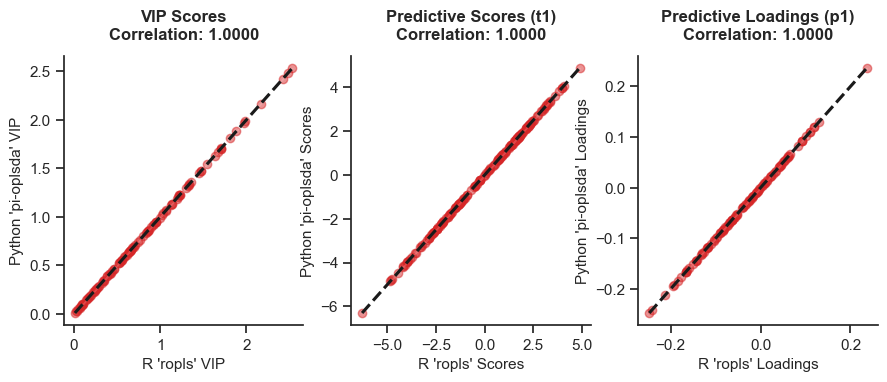

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from typing import List, Any

def plot_triple_comparison(
    py_data, r_data, titles, labels
) -> None:
    """Plots three comparison subplots in a single row for model validation."""
    # Initialize a 1x3 subplot layout
    fig, axes = plt.subplots(1, 3, figsize=(3.5*3, 3.5))
    
    for i in range(3):
        vec_py = py_data[i]
        vec_r = r_data[i]
        ax = axes[i]
        
        # Calculate Pearson correlation to show numerical identity
        corr = np.corrcoef(vec_py, vec_r)[0, 1]
        
        # Draw regression plot; points on diagonal indicate perfect match
        sns.regplot(
            x=vec_r, 
            y=vec_py, 
            ax=ax, 
            color="tab:red",
            scatter_kws={'alpha': 0.5}, 
            line_kws={'color': 'k', 'linestyle': '--'}
        )
        
        ax.set_title(
            f"{titles[i]}\nCorrelation: {corr:.4f}",
            fontsize=12, fontweight='bold', pad=12)
        ax.set_xlabel(
            f"R 'ropls' {labels[i]}",fontsize=11, fontweight='normal')
        ax.set_ylabel(
            f"Python 'pi-oplsda' {labels[i]}",fontsize=11, fontweight='normal')
        ax.tick_params(axis='both', labelsize=11)
        sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

    # plt.tight_layout()
    plt.show()

# 1. Prepare vectorized data from previously extracted metrics
py_vectors = [
    metrics_py["VIP"], 
    metrics_py["t_pred"], 
    metrics_py["p_pred"], 
]

r_vectors = [
    metrics_r["VIP"], 
    metrics_r["t_pred"], 
    metrics_r["p_pred"], 
]

# 2. Define corresponding titles and labels
titles = [
    "VIP Scores",
    "Predictive Scores (t1)", 
    "Predictive Loadings (p1)", 
]
axis_labels= ["VIP", "Scores", "Loadings"]

# 3. Generate the 1x3 comparison visualization
plot_triple_comparison(py_vectors, r_vectors, titles, axis_labels)

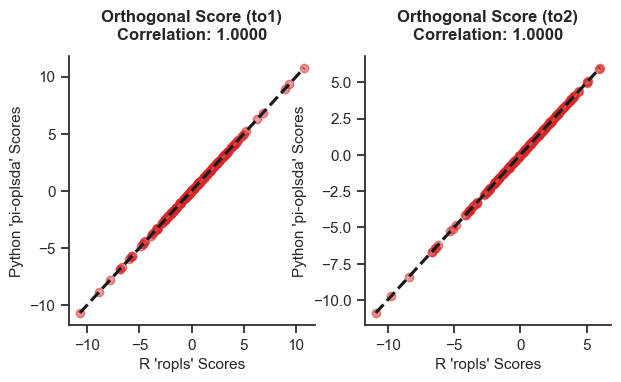

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from typing import Any, Tuple

def plot_multidim_orthogonal_comparison(
    py_ortho, r_ortho
) -> None:
    """Plots correlation for each orthogonal component in a dynamic grid."""
    # Standardize inputs to 2D arrays (N_samples, N_components)
    py_data = (
        py_ortho.reshape(-1, 1) if py_ortho.ndim == 1 else py_ortho
    )
    r_data = (
        r_ortho.reshape(-1, 1) if r_ortho.ndim == 1 else r_ortho
    )

    # Determine the number of components to plot
    n_comp_py = py_data.shape[1]
    n_comp_r = r_data.shape[1]
    n_comp = min(n_comp_py, n_comp_r)

    if n_comp == 0:
        print("No orthogonal components found to plot.")
        return

    # Create a dynamic figure layout (1 row, n_comp columns)
    fig, axes = plt.subplots(
        1, n_comp, figsize=(3.5 * n_comp, 3.5), squeeze=False
    )

    for i in range(n_comp):
        ax = axes[0, i]
        vec_py = py_data[:, i]
        vec_r = r_data[:, i]
        
        # Calculate Pearson correlation coefficient
        correlation = np.corrcoef(vec_py, vec_r)[0, 1]
        
        # Visualize correlation with a regression line
        sns.regplot(
            x=vec_r, 
            y=vec_py, 
            ax=ax, 
            color="tab:red",
            scatter_kws={'alpha': 0.5}, 
            line_kws={'color': 'k', 'linestyle': '--'}
        )
        
        ax.set_title(
            f"Orthogonal Score (to{i+1})\nCorrelation: {correlation:.4f}",
            fontsize=12, fontweight='bold', pad=12
        )
        ax.set_xlabel("R 'ropls' Scores",fontsize=11, fontweight='normal')
        ax.set_ylabel(
            "Python 'pi-oplsda' Scores",fontsize=11, fontweight='normal')
        ax.tick_params(axis='both', labelsize=11)
        sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
        
    plt.show()

# Execution: Pass the extracted orthogonal metrics
# This handles cases whether the model has 1 or multiple orthogonal components
plot_multidim_orthogonal_comparison(
    metrics_py["t_ortho"], 
    metrics_r["t_ortho"]
)

## Step 5: Publication-Ready Composite Dashboard
To conclude the benchmark, we synthesize the numerical metrics and visual diagnostics into a single, cohesive figure using the `patchworklib` package. 

This step demonstrates how to seamlessly integrate a Pandas DataFrame (as a highly customized Matplotlib table) alongside multiple Seaborn regression plots into a **2x3 grid layout**. The resulting composite image is exported at 300 DPI, providing an instant, publication-grade proof of the absolute alignment between `pi-oplsda` and the Bioconductor standard.

---

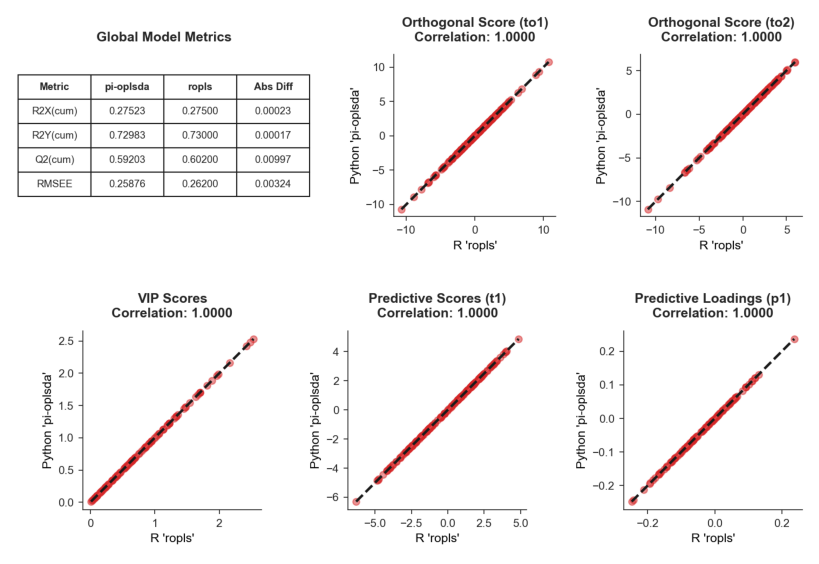

In [ ]:
import io
import numpy as np
import pandas as pd
import matplotlib.image as mpimg
import seaborn as sns
import patchworklib as pw
from typing import List, Any

# ==============================================================================
# 1. Prepare Data for the Comparison Table
# ==============================================================================
metrics = ["R2X", "R2Y", "Q2", "RMSEE"]
global_comp = pd.DataFrame({
    "Metric": ["R2X(cum)", "R2Y(cum)", "Q2(cum)", "RMSEE"],
    "pi-oplsda": [metrics_py[k] for k in metrics],
    "ropls": [metrics_r[k] for k in metrics],
})
global_comp["Abs Diff"] = np.abs(
    global_comp["pi-oplsda"] - global_comp["ropls"]
)

# ==============================================================================
# 2. Define Patchworklib Brick Generators
# ==============================================================================
def create_table_brick(df):
    """Creates a patchworklib Brick for the comparison table."""
    ax = pw.Brick(figsize=(2, 2))
    ax.axis("off")
    
    df_fmt = df.copy()
    float_cols = df_fmt.select_dtypes(
        include=["float", "float64"]
    ).columns
    
    for col in float_cols:
        df_fmt[col] = df_fmt[col].apply(lambda x: f"{x:.5f}")
        
    table = ax.table(
        cellText=df_fmt.values, 
        colLabels=df_fmt.columns, 
        loc="center", 
        cellLoc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.8, 1.8)
    
    # Apply bold styling to the table headers
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")
            
    ax.set_title(
        "Global Model Metrics", fontsize=12, fontweight="bold", pad=12)
    return ax


def create_regplot_brick(x, y, title, xlabel, ylabel):
    """Creates a patchworklib Brick for regression comparisons."""
    ax = pw.Brick(figsize=(2, 2))
    corr: float = np.corrcoef(x, y)[0, 1]
    
    sns.regplot(
        x=x, y=y, ax=ax, 
        color="tab:red",
        scatter_kws={"alpha": 0.5}, 
        line_kws={"color": "k", "linestyle": "--"}
    )
    
    ax.set_title(
        f"{title}\nCorrelation: {corr:.4f}",
        fontsize=12, 
        fontweight="bold", 
        pad=12
    )
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.tick_params(axis="both", labelsize=10)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    return ax

# ==============================================================================
# 3. Create Component Bricks
# ==============================================================================
# --- Row 1 Components ---
brick_table = create_table_brick(global_comp)

py_ortho = metrics_py["t_ortho"]
r_ortho = metrics_r["t_ortho"]
py_data = (
    py_ortho.reshape(-1, 1) if py_ortho.ndim == 1 else py_ortho
)
r_data = (
    r_ortho.reshape(-1, 1) if r_ortho.ndim == 1 else r_ortho
)

ortho_bricks = []
for i in range(2): 
    if i < min(py_data.shape[1], r_data.shape[1]):
        brick = create_regplot_brick(
            x=r_data[:, i], 
            y=py_data[:, i], 
            title=f"Orthogonal Score (to{i+1})", 
            xlabel="R 'ropls'", 
            ylabel="Python 'pi-oplsda'"
        )
    else:
        # Create an empty placeholder if the 2nd orthogonal component is absent
        brick = pw.Brick(figsize=(3.5, 3.5))
        brick.axis("off")
        brick.set_title(
            f"Orthogonal Score (to{i+1})\n(Not Present)", 
            fontsize=12, 
            pad=12
        )
    ortho_bricks.append(brick)

# --- Row 2 Components ---
brick_vip = create_regplot_brick(
    x=metrics_r["VIP"], 
    y=metrics_py["VIP"], 
    title="VIP Scores", 
    xlabel="R 'ropls'", 
    ylabel="Python 'pi-oplsda'"
)

brick_t1 = create_regplot_brick(
    x=metrics_r["t_pred"], 
    y=metrics_py["t_pred"], 
    title="Predictive Scores (t1)", 
    xlabel="R 'ropls'", 
    ylabel="Python 'pi-oplsda'"
)

brick_p1 = create_regplot_brick(
    x=metrics_r["p_pred"], 
    y=metrics_py["p_pred"], 
    title="Predictive Loadings (p1)", 
    xlabel="R 'ropls'", 
    ylabel="Python 'pi-oplsda'"
)

# ==============================================================================
# 4. Assemble and Render Layout
# ==============================================================================
# Construct the 2x3 grid using patchworklib's intuitive syntax
row1 = brick_table | ortho_bricks[0] | ortho_bricks[1]
row2 = brick_vip | brick_t1 | brick_p1

final_comp_plot = row1 / row2

# final_comp_plot.savefig(
#     fname="../assets/pi_oplsda_benchmark.png",dpi=300, bbox_inches='tight')

# Render the patchworklib layout to an in-memory buffer
buf = io.BytesIO()
final_comp_plot.savefig(buf, format='png', dpi=150, bbox_inches='tight')
buf.seek(0)

# Destroy the multiple implicit figures created by patchworklib
plt.close('all')

# Create a single, clean Figure to display the unified buffer image
figsize = (8.0, 6.0)
display_fig, display_ax = plt.subplots(figsize=figsize)
display_ax.imshow(mpimg.imread(buf, format='png'))
display_ax.axis('off')
plt.subplots_adjust(
    top=1, bottom=0, right=1, left=0, hspace=0, wspace=0
)

# Block script execution until the user closes this window
plt.show(block=True)